In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Configure pandas to display all columns when printing DataFrames
pd.set_option('display.max_columns', None)

# Use a dark background style for better visual contrast
plt.style.use('dark_background')

# Load the dataset from CSV file
df = pd.read_csv('data.csv')

In [4]:
# Display first few rows to understand data structure
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


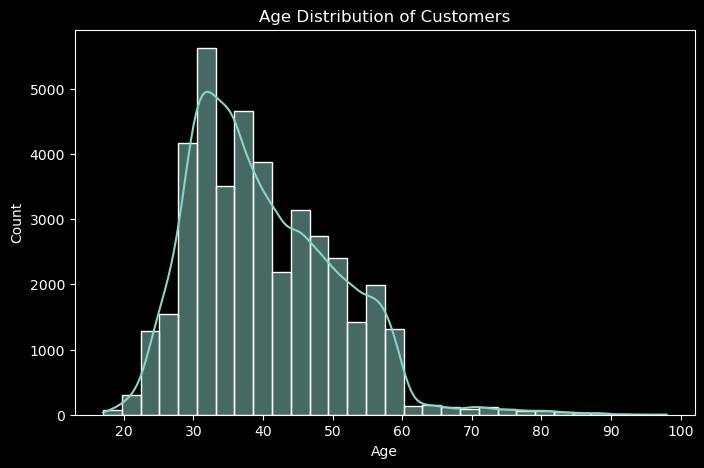

In [5]:
# Visualize the distribution of customer ages
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)

# Chart labels and title
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

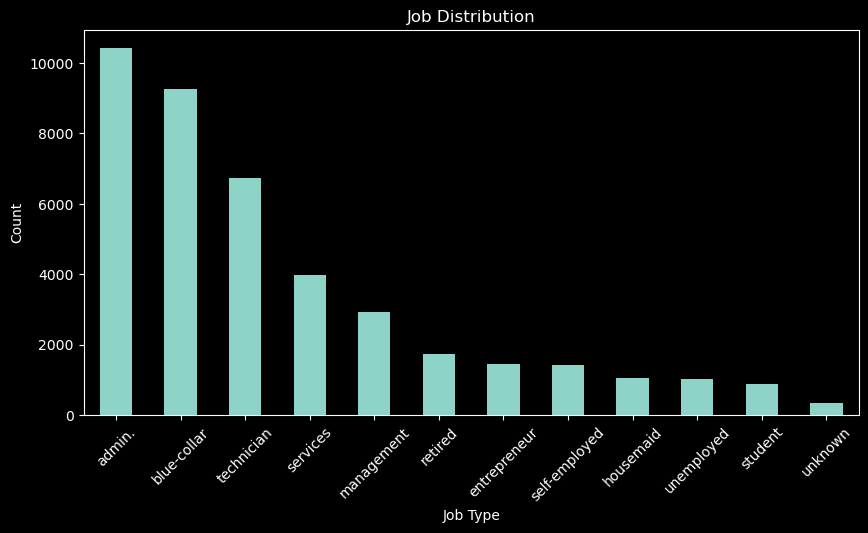

In [6]:
# Count the number of customers in each job category
plt.figure(figsize=(10,5))
df['job'].value_counts().plot(kind='bar')

# Chart labels and formatting
plt.title('Job Distribution')
plt.xlabel('Job Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

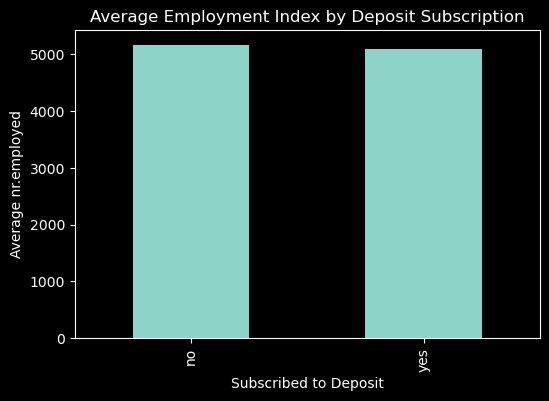

In [7]:
# Calculate average employment index based on deposit subscription status
avg_balance = df.groupby('y')['nr.employed'].mean()

# Plot the comparison
plt.figure(figsize=(6,4))
avg_balance.plot(kind='bar')

# Chart labels
plt.title('Average Employment Index by Deposit Subscription')
plt.xlabel('Subscribed to Deposit')
plt.ylabel('Average nr.employed')

plt.show()

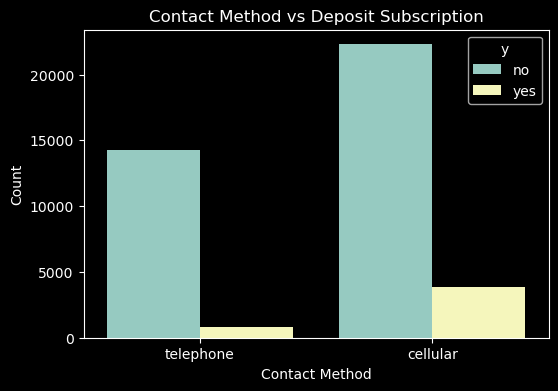

In [8]:
# Analyze effectiveness of different contact methods
plt.figure(figsize=(6,4))
sns.countplot(x='contact', hue='y', data=df)

# Chart labels
plt.title('Contact Method vs Deposit Subscription')
plt.xlabel('Contact Method')
plt.ylabel('Count')

plt.show()

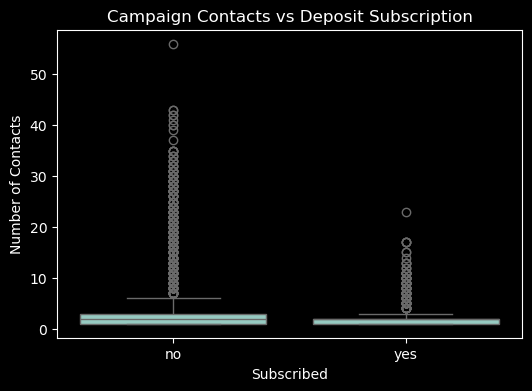

In [9]:
# Compare number of campaign contacts for subscribed vs non-subscribed customers
plt.figure(figsize=(6,4))
sns.boxplot(x='y', y='campaign', data=df)

# Chart labels
plt.title('Campaign Contacts vs Deposit Subscription')
plt.xlabel('Subscribed')
plt.ylabel('Number of Contacts')

plt.show()

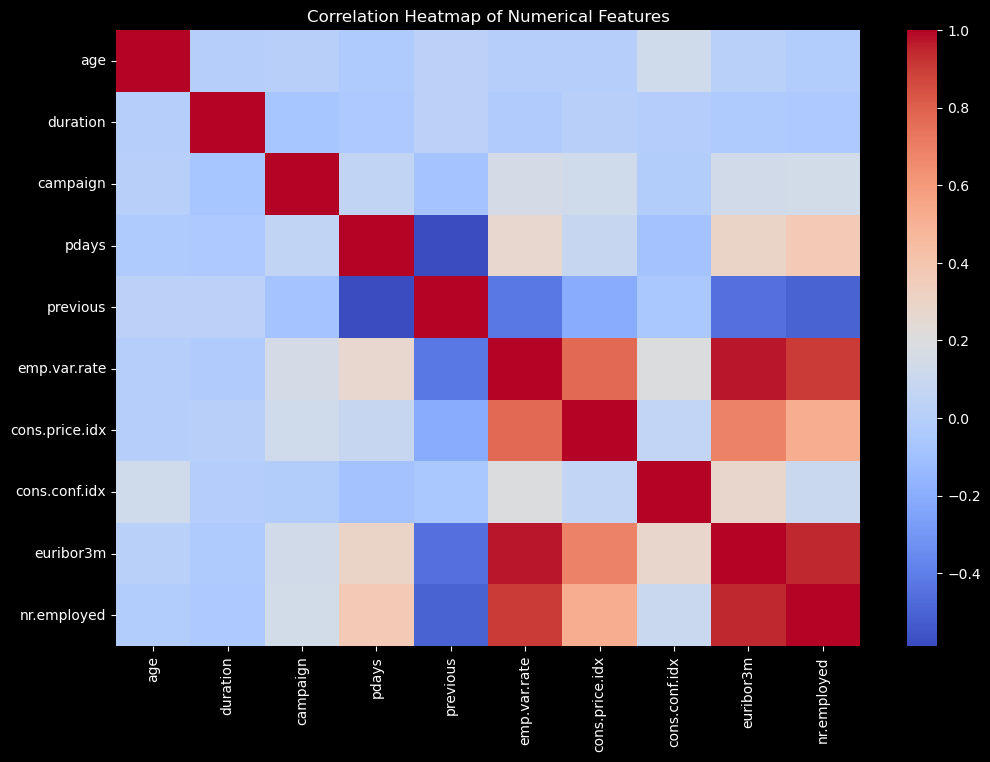

In [10]:
# Select only numerical columns for correlation analysis
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Generate correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(num_cols.corr(), cmap='coolwarm', annot=False)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [11]:
from sklearn.preprocessing import LabelEncoder

# Create a copy of the dataset to preserve original data
df_encoded = df.copy()

# Initialize label encoder
le = LabelEncoder()

# Encode all categorical (object type) columns
for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
# Separate features (X) and target variable (y)
X = df_encoded.drop('y', axis=1)   # Independent variables
y = df_encoded['y']                # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True
)

# Feature scaling to improve convergence and performance
scaler = StandardScaler()

# Fit scaler on training data and transform both sets
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize and train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9113333980771099
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      9166
           1       0.65      0.42      0.51      1131

    accuracy                           0.91     10297
   macro avg       0.79      0.70      0.73     10297
weighted avg       0.90      0.91      0.90     10297



In [ ]:
"""
--> Certain age groups and job categories are more likely to subscribe.
--> Campaign duration and number of contacts strongly impact outcomes.
--> Cellular contact method performs better than telephone.
--> Economic indicators (euribor3m, emp.var.rate) are strong predictors.
--> Logistic Regression highlights the most influential features.
"""